[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AyhamAlsuwi/ML-projects/blob/main/IT_ticket_routing_model/IT%20ticket%20routing.ipynb)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pd.set_option('display.max_rows', 50)

In [3]:
df = pd.read_csv("IT ticket routing.csv")

In [4]:
df

,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous
...,...,...
47832,git space for a project issues with adding use...,Access
47833,error sent july error hi guys can you help out...,Miscellaneous
47834,connection issues sent tuesday july connection...,Hardware
47835,error cube reports sent tuesday july error hel...,HR Support


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47837 entries, 0 to 47836
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Document     47837 non-null  object
 1   Topic_group  47837 non-null  object
dtypes: object(2)
memory usage: 747.6+ KB


In [6]:
df.isna().sum()

Document       0
Topic_group    0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
df.shape

(47837, 2)

In [9]:
df['Topic_group'].value_counts()

Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64

### the Miscellaneous class will be droped in training and testing so the model learn the healthy patterns
### moreover, after checking this class , it data are clean and not garbage, the label is human mistake

## splitting

In [12]:
from sklearn.model_selection import train_test_split

df_train , df_test = train_test_split(
   df, test_size=0.2, random_state=42, stratify=df['Topic_group']
)

In [13]:
df_train.shape , df_test.shape

((38269, 2), (9568, 2))

In [14]:
df_train = df_train.drop(df_train[df_train['Topic_group'] == 'Miscellaneous'].index)
df_test = df_test.drop(df_test[df_test['Topic_group'] == 'Miscellaneous'].index)

In [15]:
df_train.shape , df_test.shape

((32621, 2), (8156, 2))

In [16]:
df_train['Topic_group'].value_counts()

Topic_group
Hardware                 10893
HR Support                8732
Access                    5700
Storage                   2222
Purchase                  1971
Internal Project          1695
Administrative rights     1408
Name: count, dtype: int64

In [17]:
df_test['Topic_group'].value_counts()

Topic_group
Hardware                 2724
HR Support               2183
Access                   1425
Storage                   555
Purchase                  493
Internal Project          424
Administrative rights     352
Name: count, dtype: int64

In [18]:
X_train = df_train['Document']
Y_train = df_train['Topic_group']
X_test = df_test['Document']
Y_test = df_test['Topic_group']

In [19]:
X_train.shape , Y_train.shape , X_test.shape , Y_test.shape

((32621,), (32621,), (8156,), (8156,))

## Pipeline

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from custom_transformers import Flatten, average_precision

In [24]:
%load_ext autoreload
%autoreload 2

In [76]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

custom_garbage_words = ['hello', 'hi', 'dear', 'colleague', 'please', 'thanks', 'thank', 'kind', 'help', 'regards', 'best',
                       'sunday' , 'monday' , 'tuesday' , 'wednesday', 'thursday', 'friday' , 'saturday']

my_stop_words = list(ENGLISH_STOP_WORDS) + custom_garbage_words

In [78]:
preprocessing = Pipeline(steps=[
    ('imputer' , SimpleImputer(strategy='constant' , fill_value='unknown')),
    ('flatten' , Flatten()),
    ('TF-IDF' , TfidfVectorizer(
    analyzer='word',   
    min_df=0.005,               
    max_df=0.8,            
    max_features=1500,     
    ngram_range=(1, 2),    
    stop_words=my_stop_words,   
    sublinear_tf=True       
))
    
])
preprocessing

Pipeline(steps=[('imputer',
                 SimpleImputer(fill_value='unknown', strategy='constant')),
                ('flatten', Flatten()),
                ('TF-IDF',
                 TfidfVectorizer(max_df=0.8, max_features=1500, min_df=0.005,
                                 ngram_range=(1, 2),
                                 stop_words=['the', 'who', 'hence', 'herein',
                                             'found', 'were', 'then',
                                             'describe', 'her', 'too', 'one',
                                             'above', 'myself', 'hundred',
                                             'first', 'many', 'everything',
                                             'whereupon', 'con', 'became',
                                             'hers', 'should', 'twenty',
                                             'whoever', 'himself', 'how',
                                             'more', 'whatever', 'third',
                                             'show', ...],
                                 sublinear_tf=True))])

In [80]:
temp = preprocessing.fit_transform(X_train.to_frame())
temp.shape

(32621, 1080)

In [81]:
feature_names = preprocessing.named_steps['TF-IDF'].get_feature_names_out()
tfidf_scores = temp.mean(axis=0).A1
top_words = pd.DataFrame({'word': feature_names, 'score': tfidf_scores})
top_words = top_words.sort_values(by='score', ascending=False)
top_words.head(50)

,word,score
706,pm,0.043897
7,access,0.036979
888,sent,0.025111
630,new,0.021120
325,error,0.020869
480,issue,0.020249
491,july,0.019823
311,engineer,0.019490
550,log,0.019234
102,attached,0.018034


## dummy

In [85]:
from sklearn.dummy import DummyClassifier
dummy_classifier = Pipeline(steps=[
    ('preprocessing', preprocessing),
    ('dummy_classifier' , DummyClassifier(strategy='stratified'))
])

dummy_classifier

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('imputer',
                                  SimpleImputer(fill_value='unknown',
                                                strategy='constant')),
                                 ('flatten', Flatten()),
                                 ('TF-IDF',
                                  TfidfVectorizer(max_df=0.8, max_features=1500,
                                                  min_df=0.005,
                                                  ngram_range=(1, 2),
                                                  stop_words=['the', 'who',
                                                              'hence', 'herein',
                                                              'found', 'were',
                                                              'then',
                                                              'describe', 'her',
                                                              'too', 'one',
                                                              'above', 'myself',
                                                              'hundred',
                                                              'first', 'many',
                                                              'everything',
                                                              'whereupon',
                                                              'con', 'became',
                                                              'hers', 'should',
                                                              'twenty',
                                                              'whoever',
                                                              'himself', 'how',
                                                              'more',
                                                              'whatever',
                                                              'third', 'show', ...],
                                                  sublinear_tf=True))])),
                ('dummy_classifier', DummyClassifier(strategy='stratified'))])

In [87]:
from sklearn.model_selection import cross_validate

scoring = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro',
    'f1_macro': 'f1_macro',
    'average_precision': average_precision(average='macro')
}

cv_results_dummy = cross_validate(
    dummy_classifier, 
    X_train.to_frame(), Y_train, 
    cv=3, 
    scoring=scoring, 
    return_train_score=True, 
    n_jobs=15,
    verbose = 3
)


[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   3 out of   3 | elapsed:    8.9s finished


In [89]:
print("\n--- Accuracy ---")
print(f"Mean Train Accuracy:         {cv_results_dummy['train_accuracy'].mean():.4f}")
print(f"Mean Test Accuracy:          {cv_results_dummy['test_accuracy'].mean():.4f}")

print("\n--- F1 Score (Macro) ---")
print(f"Mean Train F1:               {cv_results_dummy['train_f1_macro'].mean():.4f}")
print(f"Mean Test F1:                {cv_results_dummy['test_f1_macro'].mean():.4f}")

print("\n--- Average Precision (Macro) ---")
print(f"Mean Train AP:               {cv_results_dummy['train_average_precision'].mean():.4f}")
print(f"Mean Test AP:                {cv_results_dummy['test_average_precision'].mean():.4f}")


--- Accuracy ---
Mean Train Accuracy:         0.2264
Mean Test Accuracy:          0.2271

--- F1 Score (Macro) ---
Mean Train F1:               0.1418
Mean Test F1:                0.1452

--- Average Precision (Macro) ---
Mean Train AP:               0.1427
Mean Test AP:                0.1429


## logistic regression

In [92]:
from sklearn.linear_model import LogisticRegression

logistic_reg = Pipeline(steps=[
    ('preprocessing', preprocessing),  
    ('logistic_regression', LogisticRegression(
        multi_class='ovr',   
        solver='lbfgs',      
        max_iter=1000        
    ))
])

logistic_reg

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('imputer',
                                  SimpleImputer(fill_value='unknown',
                                                strategy='constant')),
                                 ('flatten', Flatten()),
                                 ('TF-IDF',
                                  TfidfVectorizer(max_df=0.8, max_features=1500,
                                                  min_df=0.005,
                                                  ngram_range=(1, 2),
                                                  stop_words=['the', 'who',
                                                              'hence', 'herein',
                                                              'found', 'were',
                                                              'then',
                                                              'describe', 'her',
                                                              'too', 'one',
                                                              'above', 'myself',
                                                              'hundred',
                                                              'first', 'many',
                                                              'everything',
                                                              'whereupon',
                                                              'con', 'became',
                                                              'hers', 'should',
                                                              'twenty',
                                                              'whoever',
                                                              'himself', 'how',
                                                              'more',
                                                              'whatever',
                                                              'third', 'show', ...],
                                                  sublinear_tf=True))])),
                ('logistic_regression',
                 LogisticRegression(max_iter=1000, multi_class='ovr'))])

In [94]:
from sklearn.model_selection import cross_validate

scoring = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro',
    'f1_macro': 'f1_macro',
    'average_precision': average_precision(average='macro')
}

cv_results_logistic = cross_validate(
    logistic_reg, 
    X_train.to_frame(), Y_train, 
    cv=3, 
    scoring=scoring, 
    return_train_score=True, 
    n_jobs=15,
    verbose = 3
)


[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   3 out of   3 | elapsed:   11.5s finished


In [96]:
print("\n--- Accuracy ---")
print(f"Mean Train Accuracy:         {cv_results_logistic['train_accuracy'].mean():.4f}")
print(f"Mean Test Accuracy:          {cv_results_logistic['test_accuracy'].mean():.4f}")

print("\n--- Precision (Macro) ---")
print(f"Mean Train Precision:        {cv_results_logistic['train_precision_macro'].mean():.4f}")
print(f"Mean Test Precision:         {cv_results_logistic['test_precision_macro'].mean():.4f}")

print("\n--- Recall (Macro) ---")
print(f"Mean Train Recall:           {cv_results_logistic['train_recall_macro'].mean():.4f}")
print(f"Mean Test Recall:            {cv_results_logistic['test_recall_macro'].mean():.4f}")

print("\n--- F1 Score (Macro) ---")
print(f"Mean Train F1:               {cv_results_logistic['train_f1_macro'].mean():.4f}")
print(f"Mean Test F1:                {cv_results_logistic['test_f1_macro'].mean():.4f}")

print("\n--- Average Precision (Macro) ---")
print(f"Mean Train AP:               {cv_results_logistic['train_average_precision'].mean():.4f}")
print(f"Mean Test AP:                {cv_results_logistic['test_average_precision'].mean():.4f}")



--- Accuracy ---
Mean Train Accuracy:         0.8817
Mean Test Accuracy:          0.8610

--- Precision (Macro) ---
Mean Train Precision:        0.9165
Mean Test Precision:         0.9004

--- Recall (Macro) ---
Mean Train Recall:           0.8493
Mean Test Recall:            0.8239

--- F1 Score (Macro) ---
Mean Train F1:               0.8789
Mean Test F1:                0.8569

--- Average Precision (Macro) ---
Mean Train AP:               0.9502
Mean Test AP:                0.9323


In [98]:
# 1. Fit the entire pipeline on your data first
logistic_reg.fit(X_train.to_frame(), Y_train)

C:\Users\ASUS\Anaconda3.7\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('imputer',
                                  SimpleImputer(fill_value='unknown',
                                                strategy='constant')),
                                 ('flatten', Flatten()),
                                 ('TF-IDF',
                                  TfidfVectorizer(max_df=0.8, max_features=1500,
                                                  min_df=0.005,
                                                  ngram_range=(1, 2),
                                                  stop_words=['the', 'who',
                                                              'hence', 'herein',
                                                              'found', 'were',
                                                              'then',
                                                              'describe', 'her',
                                                              'too', 'one',
                                                              'above', 'myself',
                                                              'hundred',
                                                              'first', 'many',
                                                              'everything',
                                                              'whereupon',
                                                              'con', 'became',
                                                              'hers', 'should',
                                                              'twenty',
                                                              'whoever',
                                                              'himself', 'how',
                                                              'more',
                                                              'whatever',
                                                              'third', 'show', ...],
                                                  sublinear_tf=True))])),
                ('logistic_regression',
                 LogisticRegression(max_iter=1000, multi_class='ovr'))])

In [99]:


# 2. Extract the TF-IDF vectorizer and the Logistic Regression model from the nested pipeline
tfidf_step = logistic_reg.named_steps['preprocessing'].named_steps['TF-IDF']
lr_model = logistic_reg.named_steps['logistic_regression']

# 3. Retrieve the feature names (words) and the class labels
feature_names = tfidf_step.get_feature_names_out()
classes = lr_model.classes_       # Array of your 7 classes (Hardware, HR Support, etc.)
coefficients = lr_model.coef_     # Shape will be (7, number_of_features)

# 4. Loop through each class to isolate and display its top predictive features
for i, class_label in enumerate(classes):
    print(f"\n=========================================")
    print(f" CLASS: {class_label}")
    print(f"=========================================")
    
    # Get the coefficient row belonging strictly to this class
    class_coefficients = coefficients[i]
    
    # Sort the coefficients by magnitude and grab the top 10 highest indices
    top_positive_indices = np.argsort(class_coefficients)[-10:][::-1]
    
    print("Top 10 keywords driving this classification:")
    for idx in top_positive_indices:
        print(f"  -> {feature_names[idx]:<25} | Coefficient: {class_coefficients[idx]:.4f}")


 CLASS: Access
Top 10 keywords driving this classification:
  -> confluence                | Coefficient: 12.5254
  -> license                   | Coefficient: 10.3078
  -> user                      | Coefficient: 9.7410
  -> account                   | Coefficient: 9.6905
  -> card                      | Coefficient: 9.5667
  -> password                  | Coefficient: 9.2233
  -> git                       | Coefficient: 8.9241
  -> repository                | Coefficient: 8.7045
  -> accounts                  | Coefficient: 6.2463
  -> locked                    | Coefficient: 6.0044

 CLASS: Administrative rights
Top 10 keywords driving this classification:
  -> outlook                   | Coefficient: 14.5195
  -> upgrade                   | Coefficient: 10.4926
  -> issues                    | Coefficient: 5.2950
  -> install                   | Coefficient: 5.0318
  -> windows                   | Coefficient: 4.8189
  -> software                  | Coefficient: 4.6034
  -> assets

## random forest
### random forest is not the best choice with sparse matrix like TF-IDF , so I will ignore it

## XGB

In [321]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

In [323]:
Y_train_encoded = label_encoder.fit_transform(Y_train)

In [325]:
Y_train_encoded

array([3, 5, 0, ..., 3, 3, 0])

In [327]:
label_encoder.classes_

array(['Access', 'Administrative rights', 'HR Support', 'Hardware',
       'Internal Project', 'Purchase', 'Storage'], dtype=object)

In [331]:
from xgboost import XGBClassifier
xgb = Pipeline(steps=[
    ('preprocessing', preprocessing),  
    ('xgb_classifier', XGBClassifier(
        objective='multi:softprob',
        random_state=42
    ))
])

In [333]:
scoring = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro',
    'f1_macro': 'f1_macro',
    'average_precision': average_precision(average='macro')
}


cv_results_xgb = cross_validate(
    xgb, 
    X_train.to_frame(), 
    Y_train_encoded,      
    cv=3,      
    scoring=scoring,   
    return_train_score=True,      
    n_jobs=15,     
    verbose=3     
)

[Parallel(n_jobs=15)]: Using backend LokyBackend with 15 concurrent workers.
[Parallel(n_jobs=15)]: Done   3 out of   3 | elapsed:  1.8min finished


In [466]:
print("\n--- Accuracy ---")
print(f"Mean Train Accuracy:         {cv_results_xgb['train_accuracy'].mean():.4f}")
print(f"Mean Test Accuracy:          {cv_results_xgb['test_accuracy'].mean():.4f}")

print("\n--- Precision (Macro) ---")
print(f"Mean Train Precision:        {cv_results_xgb['train_precision_macro'].mean():.4f}")
print(f"Mean Test Precision:         {cv_results_xgb['test_precision_macro'].mean():.4f}")

print("\n--- Recall (Macro) ---")
print(f"Mean Train Recall:           {cv_results_xgb['train_recall_macro'].mean():.4f}")
print(f"Mean Test Recall:            {cv_results_xgb['test_recall_macro'].mean():.4f}")

print("\n--- F1 Score (Macro) ---")
print(f"Mean Train F1:               {cv_results_xgb['train_f1_macro'].mean():.4f}")
print(f"Mean Test F1:                {cv_results_xgb['test_f1_macro'].mean():.4f}")

print("\n--- Average Precision (Macro) ---")
print(f"Mean Train AP:               {cv_results_xgb['train_average_precision'].mean():.4f}")
print(f"Mean Test AP:                {cv_results_xgb['test_average_precision'].mean():.4f}")


--- Accuracy ---
Mean Train Accuracy:         0.9614
Mean Test Accuracy:          0.8716

--- Precision (Macro) ---
Mean Train Precision:        0.9790
Mean Test Precision:         0.8897

--- Recall (Macro) ---
Mean Train Recall:           0.9638
Mean Test Recall:            0.8514

--- F1 Score (Macro) ---
Mean Train F1:               0.9711
Mean Test F1:                0.8689

--- Average Precision (Macro) ---
Mean Train AP:               0.9952
Mean Test AP:                0.9365


# on default patrameters the logistic and xgb got the same scores 

## tuning logistic regeression

In [103]:
from sklearn.linear_model import LogisticRegression

logistic_reg_v2 = Pipeline(steps=[
    ('preprocessing', preprocessing),  
    ('logistic_regression', LogisticRegression(
        multi_class='ovr',   
        solver='lbfgs',      
        max_iter=1000     
    ))
])

logistic_reg_v2

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('imputer',
                                  SimpleImputer(fill_value='unknown',
                                                strategy='constant')),
                                 ('flatten', Flatten()),
                                 ('TF-IDF',
                                  TfidfVectorizer(max_df=0.8, max_features=1500,
                                                  min_df=0.005,
                                                  ngram_range=(1, 2),
                                                  stop_words=['the', 'who',
                                                              'hence', 'herein',
                                                              'found', 'were',
                                                              'then',
                                                              'describe', 'her',
                                                              'too', 'one',
                                                              'above', 'myself',
                                                              'hundred',
                                                              'first', 'many',
                                                              'everything',
                                                              'whereupon',
                                                              'con', 'became',
                                                              'hers', 'should',
                                                              'twenty',
                                                              'whoever',
                                                              'himself', 'how',
                                                              'more',
                                                              'whatever',
                                                              'third', 'show', ...],
                                                  sublinear_tf=True))])),
                ('logistic_regression',
                 LogisticRegression(max_iter=1000, multi_class='ovr'))])

In [105]:
from sklearn.model_selection import GridSearchCV


scoring = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro',
    'f1_macro': 'f1_macro',
    'average_precision': average_precision(average='macro')
}

param_grid = {
    'logistic_regression__C': [0.01, 0.05, 0.1, 0.5,  1.0, 3, 6, 10.0],
    'logistic_regression__class_weight': [None, 'balanced']    
}


grid_search_logistic_v2 = GridSearchCV(
    estimator=logistic_reg_v2, 
    param_grid=param_grid,
    cv=3,                      
    scoring=scoring,           
    refit='average_precision',  
    return_train_score=True,
    n_jobs=15,
    verbose=3
)


grid_search_logistic_v2.fit(X_train.to_frame(), Y_train)


Fitting 3 folds for each of 16 candidates, totalling 48 fits


C:\Users\ASUS\Anaconda3.7\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        Pipeline(steps=[('imputer',
                                                         SimpleImputer(fill_value='unknown',
                                                                       strategy='constant')),
                                                        ('flatten', Flatten()),
                                                        ('TF-IDF',
                                                         TfidfVectorizer(max_df=0.8,
                                                                         max_features=1500,
                                                                         min_df=0.005,
                                                                         ngram_range=(1,
                                                                                      2),
                                                                         stop_words=['the',
                                                                                     'who',
                                                                                     'hence',
                                                                                     'herein',
                                                                                     'found',
                                                                                     'were',
                                                                                     'then',
                                                                                     'describe',
                                                                                     'her',
                                                                                     'too',
                                                                                     'one',
                                                                                     'abov...
             param_grid={'logistic_regression__C': [0.01, 0.05, 0.1, 0.5, 1.0,
                                                    3, 6, 10.0],
                         'logistic_regression__class_weight': [None,
                                                               'balanced']},
             refit='average_precision', return_train_score=True,
             scoring={'accuracy': 'accuracy',
                      'average_precision': <function average_precision.<locals>.multiclass_ap_scorer at 0x000001E2ECDEBB00>,
                      'f1_macro': 'f1_macro',
                      'precision_macro': 'precision_macro',
                      'recall_macro': 'recall_macro'},
             verbose=3)

In [117]:
logistic_reg_v2 = grid_search_logistic_v2.best_estimator_

In [119]:
grid_search_logistic_v2.best_params_

{'logistic_regression__C': 3, 'logistic_regression__class_weight': None}

In [121]:

cv_results_df_logistic = pd.DataFrame(grid_search_logistic_v2.cv_results_)

# 2. Extract the row matching the best estimator's index
best_row = cv_results_df_logistic.iloc[grid_search_logistic_v2.best_index_]

print(f"Accuracy:        [Train] {best_row['mean_train_accuracy']:.4f}  |  [Test] {best_row['mean_test_accuracy']:.4f}")
print(f"Precision Macro: [Train] {best_row['mean_train_precision_macro']:.4f}  |  [Test] {best_row['mean_test_precision_macro']:.4f}")
print(f"Recall Macro:    [Train] {best_row['mean_train_recall_macro']:.4f}  |  [Test] {best_row['mean_test_recall_macro']:.4f}")
print(f"F1 Macro:        [Train] {best_row['mean_train_f1_macro']:.4f}  |  [Test] {best_row['mean_test_f1_macro']:.4f}")
print(f"Avg Precision:   [Train] {best_row['mean_train_average_precision']:.4f}  |  [Test] {best_row['mean_test_average_precision']:.4f}")


Accuracy:        [Train] 0.8947  |  [Test] 0.8661
Precision Macro: [Train] 0.9205  |  [Test] 0.8945
Recall Macro:    [Train] 0.8753  |  [Test] 0.8417
F1 Macro:        [Train] 0.8960  |  [Test] 0.8655
Avg Precision:   [Train] 0.9589  |  [Test] 0.9326


## tuning xgb

In [411]:
from xgboost import XGBClassifier
xgb_v2 = Pipeline(steps=[
    ('preprocessing', preprocessing),  
    ('xgb_classifier', XGBClassifier(
        objective='multi:softprob',
        random_state=42
    ))
])

In [427]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils.class_weight import compute_sample_weight
from scipy.stats import randint

sample_weight = compute_sample_weight(class_weight='balanced', y=Y_train_encoded)

scoring = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro',
    'f1_macro': 'f1_macro',
    'average_precision': average_precision(average='macro')
}


param_dist = {
    'xgb_classifier__n_estimators': randint(100, 400),        
    'xgb_classifier__max_depth': randint(3, 7),               
    'xgb_classifier__learning_rate': [0.01, 0.05, 0.1, 0.5,  1.0, 3],       
    'xgb_classifier__min_child_weight': randint(3, 15),        
    'xgb_classifier__colsample_bytree': [ 0.6, 0.8, 0.9, 1],     
}

random_search_xgb_v2 =RandomizedSearchCV(
    estimator=xgb_v2,       
    param_distributions=param_dist,
    n_iter=30,                    
    cv=3,
    scoring=scoring,
    refit='average_precision',    
    return_train_score=True,
    random_state=42,              
    n_jobs=15,
    verbose=3
)

random_search_xgb_v2.fit( X_train.to_frame(), Y_train_encoded,  xgb_classifier__sample_weight=sample_weight)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              Pipeline(steps=[('imputer',
                                                               SimpleImputer(fill_value='unknown',
                                                                             strategy='constant')),
                                                              ('flatten',
                                                               Flatten()),
                                                              ('TF-IDF',
                                                               TfidfVectorizer(max_df=0.8,
                                                                               max_features=2500,
                                                                               min_df=0.005,
                                                                               ngram_range=(1,
                                                                                            2),
                                                                               stop_words='english',
                                                                               sublinear_tf=True))])),
                                             ('xgb_classifier',
                                              XGBClassifier(base_score=None...
                                        'xgb_classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000275F5A914C0>},
                   random_state=42, refit='average_precision',
                   return_train_score=True,
                   scoring={'accuracy': 'accuracy',
                            'average_precision': <function average_precision.<locals>.multiclass_ap_scorer at 0x00000275E24C8B80>,
                            'f1_macro': 'f1_macro',
                            'precision_macro': 'precision_macro',
                            'recall_macro': 'recall_macro'},
                   verbose=3)

In [115]:
xgb_v2 = random_search_xgb_v2.best_estimator_

NameError: name 'random_search_xgb_v2' is not defined

In [431]:
random_search_xgb_v2.best_params_

{'xgb_classifier__colsample_bytree': 1,
 'xgb_classifier__learning_rate': 0.5,
 'xgb_classifier__max_depth': 4,
 'xgb_classifier__min_child_weight': 3,
 'xgb_classifier__n_estimators': 147}

In [447]:
cv_results_df_xgb_v2 = pd.DataFrame(random_search_xgb_v2.cv_results_)

# 2. Extract the row matching the best estimator's index
best_row = cv_results_df_xgb_v2.iloc[random_search_xgb_v2.best_index_]

print(f"Accuracy:        [Train] {best_row['mean_train_accuracy']:.4f}  |  [Test] {best_row['mean_test_accuracy']:.4f}")
print(f"Precision Macro: [Train] {best_row['mean_train_precision_macro']:.4f}  |  [Test] {best_row['mean_test_precision_macro']:.4f}")
print(f"Recall Macro:    [Train] {best_row['mean_train_recall_macro']:.4f}  |  [Test] {best_row['mean_test_recall_macro']:.4f}")
print(f"F1 Macro:        [Train] {best_row['mean_train_f1_macro']:.4f}  |  [Test] {best_row['mean_test_f1_macro']:.4f}")
print(f"Avg Precision:   [Train] {best_row['mean_train_average_precision']:.4f}  |  [Test] {best_row['mean_test_average_precision']:.4f}")


Accuracy:        [Train] 0.9496  |  [Test] 0.8696
Precision Macro: [Train] 0.9464  |  [Test] 0.8580
Recall Macro:    [Train] 0.9729  |  [Test] 0.8768
F1 Macro:        [Train] 0.9590  |  [Test] 0.8668
Avg Precision:   [Train] 0.9933  |  [Test] 0.9351


## xgb V3

In [435]:
from xgboost import XGBClassifier
xgb_v3 = Pipeline(steps=[
    ('preprocessing', preprocessing),  
    ('xgb_classifier', XGBClassifier(
        objective='multi:softprob',
        random_state=42
    ))
])

In [439]:
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_sample_weight

sample_weight = compute_sample_weight(class_weight='balanced', y=Y_train_encoded)


scoring = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro',
    'f1_macro': 'f1_macro',
    'average_precision': average_precision(average='macro')
}

param_grid = {
    'xgb_classifier__n_estimators': [150],        
    'xgb_classifier__max_depth': [4 ,6, 8 ,10 ,12, 14, 16],               
    'xgb_classifier__learning_rate': [0.5],       
    'xgb_classifier__min_child_weight': [3,5],        
    'xgb_classifier__colsample_bytree': [ 1],  
}


grid_search_xgb_v3 = GridSearchCV(
    estimator=xgb_v3, 
    param_grid=param_grid,
    cv=3,                      
    scoring=scoring,           
    refit='average_precision',  
    return_train_score=True,
    n_jobs=15,
    verbose=3
)


grid_search_xgb_v3.fit(X_train.to_frame(), Y_train_encoded,  xgb_classifier__sample_weight=sample_weight)


Fitting 3 folds for each of 14 candidates, totalling 42 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        Pipeline(steps=[('imputer',
                                                         SimpleImputer(fill_value='unknown',
                                                                       strategy='constant')),
                                                        ('flatten', Flatten()),
                                                        ('TF-IDF',
                                                         TfidfVectorizer(max_df=0.8,
                                                                         max_features=2500,
                                                                         min_df=0.005,
                                                                         ngram_range=(1,
                                                                                      2),
                                                                         stop_words='english',
                                                                         sublinear_tf=True))])),
                                       ('xgb_classifier',
                                        XGBClassifier(base_score=None,
                                                      boost...
                         'xgb_classifier__min_child_weight': [3, 5],
                         'xgb_classifier__n_estimators': [150]},
             refit='average_precision', return_train_score=True,
             scoring={'accuracy': 'accuracy',
                      'average_precision': <function average_precision.<locals>.multiclass_ap_scorer at 0x00000275EDFAFB00>,
                      'f1_macro': 'f1_macro',
                      'precision_macro': 'precision_macro',
                      'recall_macro': 'recall_macro'},
             verbose=3)

In [441]:
xgb_v3 = grid_search_xgb_v3.best_estimator_

In [443]:
grid_search_xgb_v3.best_params_

{'xgb_classifier__colsample_bytree': 1,
 'xgb_classifier__learning_rate': 0.5,
 'xgb_classifier__max_depth': 4,
 'xgb_classifier__min_child_weight': 5,
 'xgb_classifier__n_estimators': 150}

In [445]:
cv_results_df_xgb_v3 = pd.DataFrame(grid_search_xgb_v3.cv_results_)

# 2. Extract the row matching the best estimator's index
best_row = cv_results_df_xgb_v3.iloc[grid_search_xgb_v3.best_index_]

print(f"Accuracy:        [Train] {best_row['mean_train_accuracy']:.4f}  |  [Test] {best_row['mean_test_accuracy']:.4f}")
print(f"Precision Macro: [Train] {best_row['mean_train_precision_macro']:.4f}  |  [Test] {best_row['mean_test_precision_macro']:.4f}")
print(f"Recall Macro:    [Train] {best_row['mean_train_recall_macro']:.4f}  |  [Test] {best_row['mean_test_recall_macro']:.4f}")
print(f"F1 Macro:        [Train] {best_row['mean_train_f1_macro']:.4f}  |  [Test] {best_row['mean_test_f1_macro']:.4f}")
print(f"Avg Precision:   [Train] {best_row['mean_train_average_precision']:.4f}  |  [Test] {best_row['mean_test_average_precision']:.4f}")


Accuracy:        [Train] 0.9443  |  [Test] 0.8695
Precision Macro: [Train] 0.9392  |  [Test] 0.8550
Recall Macro:    [Train] 0.9693  |  [Test] 0.8796
F1 Macro:        [Train] 0.9534  |  [Test] 0.8664
Avg Precision:   [Train] 0.9916  |  [Test] 0.9360


# The XGB and logistic regeression got the same scores even after hard tuning, so I will choose logistic 
## (no need for complexity)

In [125]:
import joblib

In [127]:
joblib.dump(logistic_reg_v2 , 'best model.pkl')

['best model.pkl']

In [129]:
import joblib
best_model = joblib.load('best model.pkl')

## Performance analysis

In [132]:
from sklearn.model_selection import cross_val_predict

# 1. Get the actual predicted class labels (e.g., 'Hardware', 'Access')
cv_predicted_classes = cross_val_predict(
    best_model, 
    X_train.to_frame(),  
    Y_train, 
    cv=3, 
    n_jobs=15
)

# 2. Get the raw probability scores for all 7 classes
cv_probabilities = cross_val_predict(
    best_model, 
    X_train.to_frame(), 
    Y_train, 
    cv=3, 
    n_jobs=15,
    method='predict_proba'
)

In [134]:
cv_predicted_classes

array(['Hardware', 'Purchase', 'Access', ..., 'Hardware', 'Hardware',
       'Access'], dtype=object)

In [136]:
cv_probabilities

array([[9.25970420e-03, 3.89050003e-02, 3.48593751e-02, ...,
        2.27602530e-01, 5.41746524e-03, 2.14704189e-03],
       [1.10943764e-03, 7.98258622e-04, 9.53862213e-03, ...,
        6.34500938e-03, 9.21179390e-01, 1.20032735e-02],
       [9.96856957e-01, 3.32914976e-04, 1.16015669e-03, ...,
        1.60223637e-04, 9.09478044e-04, 3.91596358e-04],
       ...,
       [2.11925263e-02, 5.42862846e-03, 1.08302910e-02, ...,
        1.80764970e-02, 3.67395827e-03, 4.93706798e-02],
       [9.46564604e-04, 1.25848129e-03, 5.18799514e-03, ...,
        1.25659132e-03, 3.17619721e-03, 2.35964503e-03],
       [9.38749205e-01, 1.83279763e-03, 3.59827814e-02, ...,
        2.43892003e-03, 1.38022178e-03, 2.45245270e-03]])

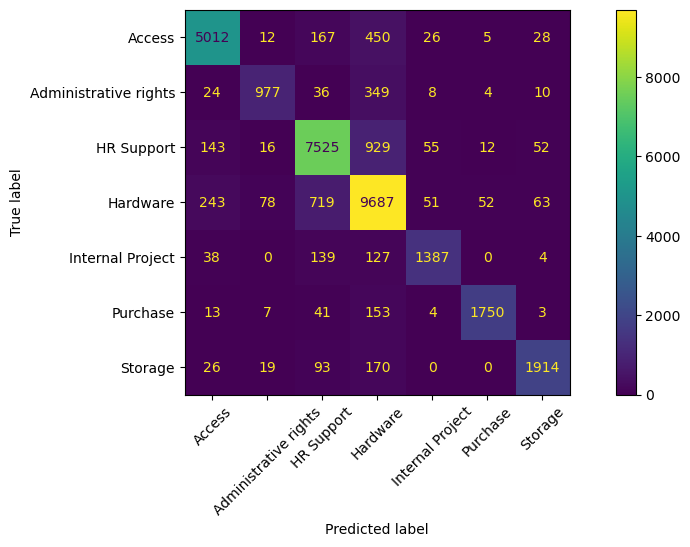

In [137]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(Y_train, cv_predicted_classes , ax = ax, xticks_rotation=45);

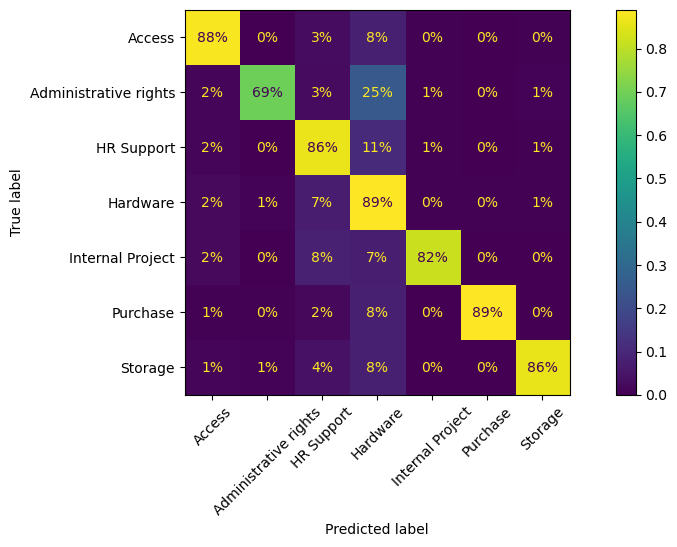

In [139]:
fig, ax = plt.subplots(figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(Y_train, cv_predicted_classes , ax = ax, xticks_rotation=45 , normalize="true", values_format=".0%");

## the model struggles with Administrative rights

In [141]:
Y_train_binaryLabel = (Y_train == 'Administrative rights')

In [142]:
best_model.classes_

array(['Access', 'Administrative rights', 'HR Support', 'Hardware',
       'Internal Project', 'Purchase', 'Storage'], dtype=object)

In [143]:
Administrative_rights_probabilities = cv_probabilities[:,1]
Administrative_rights_probabilities

array([0.038905  , 0.00079826, 0.00033291, ..., 0.00542863, 0.00125848,
       0.0018328 ])

In [145]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(Y_train_binaryLabel, Administrative_rights_probabilities)

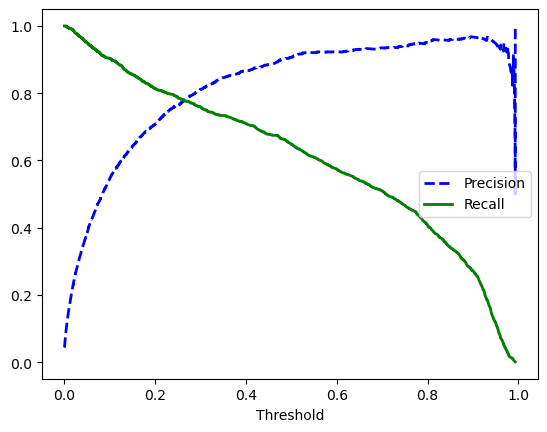

In [146]:
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.xlabel("Threshold")
plt.legend(loc="center right");

In [147]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [148]:
from custom_transformers import ThresholdWrapper_and_ZeroVectorCatcher

In [150]:
tuned_threshold_model_no_cut_off = ThresholdWrapper_and_ZeroVectorCatcher(best_model , {'Administrative rights': 0.25})

In [153]:
cv_predicted_classes_tuned_threshold = cross_val_predict(
    tuned_threshold_model_no_cut_off, 
    X_train.to_frame(),  
    Y_train, 
    cv=3, 
    n_jobs=15
)

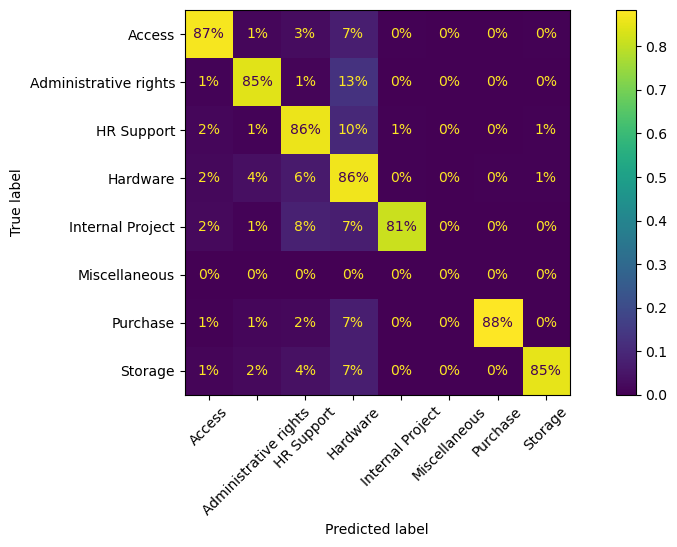

In [155]:
fig, ax = plt.subplots(figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(Y_train, cv_predicted_classes_tuned_threshold , ax = ax, xticks_rotation=45 
                                        , normalize="true", values_format=".0%");

## Finding the floor probabilities to set a cut-off for Miscellaneous class 

In [158]:
cv_probabilities

array([[9.25970420e-03, 3.89050003e-02, 3.48593751e-02, ...,
        2.27602530e-01, 5.41746524e-03, 2.14704189e-03],
       [1.10943764e-03, 7.98258622e-04, 9.53862213e-03, ...,
        6.34500938e-03, 9.21179390e-01, 1.20032735e-02],
       [9.96856957e-01, 3.32914976e-04, 1.16015669e-03, ...,
        1.60223637e-04, 9.09478044e-04, 3.91596358e-04],
       ...,
       [2.11925263e-02, 5.42862846e-03, 1.08302910e-02, ...,
        1.80764970e-02, 3.67395827e-03, 4.93706798e-02],
       [9.46564604e-04, 1.25848129e-03, 5.18799514e-03, ...,
        1.25659132e-03, 3.17619721e-03, 2.35964503e-03],
       [9.38749205e-01, 1.83279763e-03, 3.59827814e-02, ...,
        2.43892003e-03, 1.38022178e-03, 2.45245270e-03]])

In [160]:
best_model.classes_

array(['Access', 'Administrative rights', 'HR Support', 'Hardware',
       'Internal Project', 'Purchase', 'Storage'], dtype=object)

In [162]:
right_predections_mask = (Y_train == cv_predicted_classes)

In [164]:
true_predections = Y_train[right_predections_mask]

In [166]:
proba_for_winner_label =  (cv_probabilities.max(axis = 1))[right_predections_mask]

In [167]:
for i in best_model.classes_:
    i_class_mask = (i == true_predections)
    i_class_probas = proba_for_winner_label[i_class_mask]
    print('lowest proba for class', i, 'is :\n', f'{i_class_probas.min():.4f}' ,end = '\n\n')

lowest proba for class Access is :
 0.2635

lowest proba for class Administrative rights is :
 0.2505

lowest proba for class HR Support is :
 0.2780

lowest proba for class Hardware is :
 0.2925

lowest proba for class Internal Project is :
 0.3079

lowest proba for class Purchase is :
 0.3468

lowest proba for class Storage is :
 0.2688



In [168]:
final_model_tuned_thresholds = ThresholdWrapper_and_ZeroVectorCatcher(best_model ,{'Administrative rights': 0.25} ,
                                                fallback_label='Miscellaneous', min_confidence=0.24 )

# Test set

In [170]:
test_predections = final_model_tuned_thresholds.predict(X_test.to_frame())


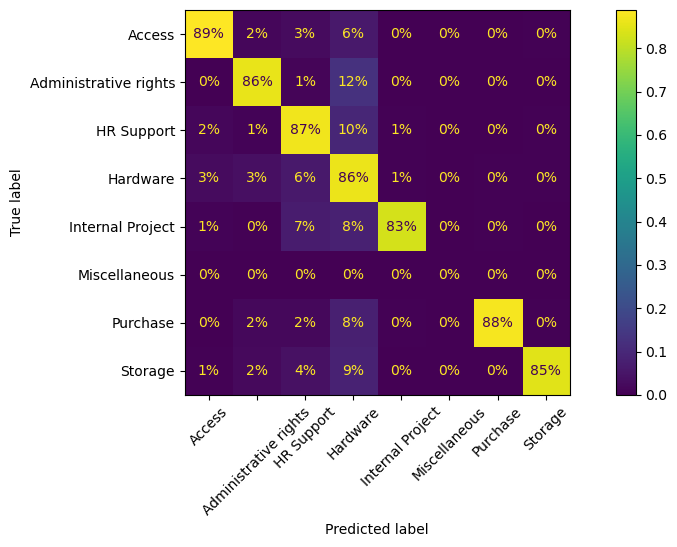

In [171]:
fig, ax = plt.subplots(figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(Y_test, test_predections , ax = ax, xticks_rotation=45 
                                        , normalize="true", values_format=".0%");

In [197]:
from sklearn.metrics import classification_report


report = classification_report(Y_test, test_predections,zero_division=True)

print(report)

                       precision    recall  f1-score   support

               Access       0.92      0.89      0.90      1425
Administrative rights       0.66      0.86      0.74       352
           HR Support       0.88      0.87      0.87      2183
             Hardware       0.84      0.86      0.85      2724
     Internal Project       0.91      0.83      0.87       424
        Miscellaneous       0.00      1.00      0.00         0
             Purchase       0.97      0.88      0.92       493
              Storage       0.94      0.85      0.89       555

             accuracy                           0.87      8156
            macro avg       0.76      0.88      0.76      8156
         weighted avg       0.87      0.87      0.87      8156



In [199]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

In [203]:
f1 = f1_score(Y_test, test_predections, average='macro' , zero_division=True)
precision = precision_score(Y_test, test_predections, average='macro' , zero_division=True)
recall = recall_score(Y_test, test_predections, average='macro' , zero_division=True)
accuracy = accuracy_score(Y_test, test_predections )

In [205]:
f1 , precision , precision ,accuracy

(0.7555833968798953, 0.7619648443909959, 0.7619648443909959, 0.866969102501226)

In [857]:
import joblib
import platform
import sklearn
import xgboost
import pandas
import numpy
import scipy
# ==========================================
# 2. Generate Strict requirements.txt
# ==========================================
req_filename = 'requirements.txt'

with open(req_filename, 'w') as f:
    f.write("# ==========================================\n")
    f.write(f"# Python Version Required: {platform.python_version()}\n")
    f.write("# (Ensure your server runs this exact minor version, e.g., 3.10.x)\n")
    f.write("# ==========================================\n\n")
    
    # Write the exact versions currently running in your RAM
    f.write(f"scikit-learn=={sklearn.__version__}\n")
    f.write(f"xgboost=={xgboost.__version__}\n")
    f.write(f"pandas=={pandas.__version__}\n")
    f.write(f"numpy=={numpy.__version__}\n")
    f.write(f"scipy=={scipy.__version__}\n")
    
    # Joblib is required to load the model back up
    f.write(f"joblib=={joblib.__version__}\n")